In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [140]:
df = pd.read_csv(
    "Telco-Customer-Churn.csv",
    true_values=["Yes"],
    false_values=["No"],
    dtype={
        "SeniorCitizen": np.bool_,
        "tenure": np.int8,
        "MonthlyCharges": np.float32
    }
)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,True,False,1,False,No phone service,DSL,No,...,No,No,No,No,Month-to-month,True,Electronic check,29.850000,29.85,False
1,5575-GNVDE,Male,False,False,False,34,True,No,DSL,Yes,...,Yes,No,No,No,One year,False,Mailed check,56.950001,1889.5,False
2,3668-QPYBK,Male,False,False,False,2,True,No,DSL,Yes,...,No,No,No,No,Month-to-month,True,Mailed check,53.849998,108.15,True
3,7795-CFOCW,Male,False,False,False,45,False,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,9237-HQITU,Female,False,False,False,2,True,No,Fiber optic,No,...,No,No,No,No,Month-to-month,True,Electronic check,70.699997,151.65,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,False,True,True,24,True,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,True,Mailed check,84.800003,1990.5,False
7039,2234-XADUH,Female,False,True,True,72,True,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,True,Credit card (automatic),103.199997,7362.9,False
7040,4801-JZAZL,Female,False,True,True,11,False,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,True,Electronic check,29.600000,346.45,False
7041,8361-LTMKD,Male,True,True,False,4,True,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,True,Mailed check,74.400002,306.6,True


In [141]:
pd.DataFrame(df["gender"].value_counts())    

,count
gender,
Male,3555
Female,3488


In [142]:
pd.DataFrame(df.loc[df["PhoneService"]== False ,["PhoneService"]].value_counts())

,count
PhoneService,
False,682


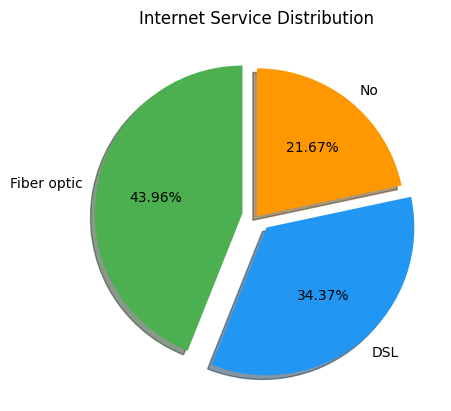

In [143]:
InternetService=df["InternetService"].value_counts()
InternetService1= InternetService.index
InternetService2= InternetService.values
colors = ["#4CAF50","#2196F3","#FF9800"]
plt.pie(
    InternetService2,
    labels=InternetService1,
    explode=[0.1, 0.1, 0],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    shadow=True
)
plt.title("Internet Service Distribution")
plt.show()

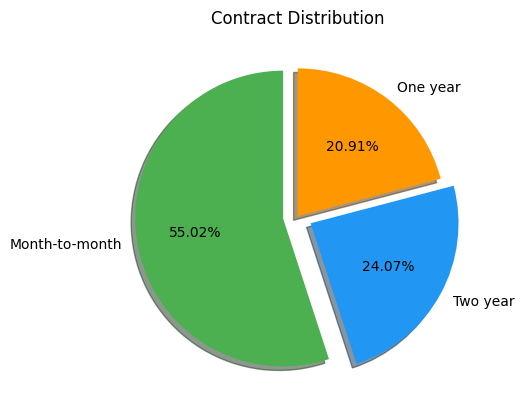

In [144]:
Contract=df["Contract"].value_counts()
Contract1= Contract.index
Contract2= Contract.values
colors = ["#4CAF50","#2196F3","#FF9800"]
plt.pie(
    Contract2,
    labels=Contract1,
    explode=[0.1, 0.1, 0],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    shadow=True
)
plt.title("Contract Distribution")
plt.show()

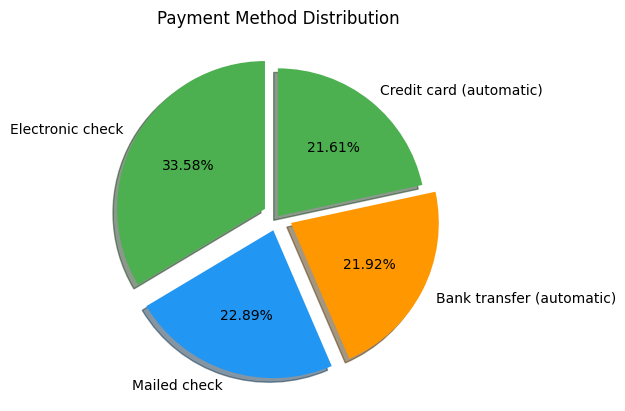

In [145]:
PaymentMethod=df["PaymentMethod"].value_counts()
PaymentMethod1= PaymentMethod.index
PaymentMethod2= PaymentMethod.values
colors = ["#4CAF50","#2196F3","#FF9800"]
plt.pie(
    PaymentMethod2,
    labels=PaymentMethod1,
    explode=[0.1, 0.1, 0.1,0],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    shadow=True
)
plt.title("Payment Method Distribution")
plt.show()

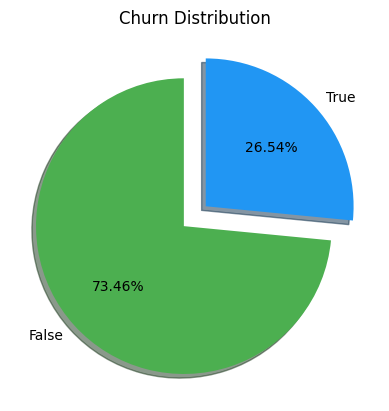

In [146]:
Churn=df["Churn"].value_counts()
Churn1= Churn.index
Churn2= Churn.values
colors = ["#4CAF50","#2196F3","#FF9800"]
plt.pie(
    Churn2,
    labels=Churn1,
    explode=[0.1, 0.1],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90,
    shadow=True
)
plt.title("Churn Distribution")
plt.show()

In [147]:
max_tenure = df["tenure"].max()
max_tenure_customers = df[df["tenure"] == max_tenure][["customerID", "tenure"]]
pd.DataFrame(max_tenure_customers)



,customerID,tenure
28,5248-YGIJN,72
35,6234-RAAPL,72
59,5954-BDFSG,72
62,0526-SXDJP,72
94,9848-JQJTX,72
...,...,...
6982,8468-FZTOE,72
7007,2274-XUATA,72
7022,7203-OYKCT,72
7037,2569-WGERO,72


In [148]:
max_charges = df["TotalCharges"].max()
max_charges_customers = df[df["TotalCharges"] == max_charges][["customerID", "TotalCharges"]]
pd.DataFrame(max_charges_customers)

,customerID,TotalCharges
2845,9093-FPDLG,999.9


In [149]:
df['TotalCharges'] = np.where(df['TotalCharges'] == " ", 0.0, df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].astype(np.float32)

In [150]:
df = pd.get_dummies(df, columns=["gender", "MultipleLines", "InternetService", "OnlineSecurity" ,"OnlineBackup" ,"DeviceProtection" ,"TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"])

In [151]:
X = df.drop(columns=["customerID", "Churn"]) 
Y = df["Churn"]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=4000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [152]:
round(model.score(x_test, y_test) * 100, 2)

82.04

In [153]:
prediction_1 = model.predict(x_test)
pd.DataFrame({"unit_price": x_test["MonthlyCharges"],"tenure":x_test["tenure"],"TotalCharges":x_test["TotalCharges"],"Churn":y_test, "Predicted_Churn": prediction_1}).head(10)


,unit_price,tenure,TotalCharges,Churn,Predicted_Churn
185,24.799999,1,24.799999,True,True
2715,25.250000,41,996.450012,False,False
3825,19.350000,52,1031.699951,False,False
1807,76.349998,1,76.349998,True,True
132,50.549999,67,3260.100098,False,False
1263,89.599998,68,6127.600098,True,False
3732,77.150002,23,1759.400024,False,False
1672,72.099998,72,5016.649902,False,False
811,104.000000,70,7250.149902,True,False
2526,19.400000,1,19.400000,True,False


In [154]:
prediction = model.predict(x_test)
print(f"Correct: {x_test[y_test == prediction].shape[0]} ")
print(f"Not Correct: {x_test[y_test != prediction].shape[0]} ")

Correct: 1156 
Not Correct: 253 
